*   Warren Jones
*   COSC 502 Data Science and Artificial Intelligence
*   Morgan State University
*   Final Project
*   May 8, 2026

In [206]:
# Load Basic libraries
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings('ignore')

# Load Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Load NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize

# Load Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import label_binarize

# Load ANN
from sklearn.neural_network import MLPClassifier

In [207]:
# Download NLTK Resources

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

# QUESTION 1 - A

Read the csv file in python Pandas DataFrame and make 70% as training and
30% as test sets.

In [208]:
# Load Dataset and Skip Bad Lines

df = pd.read_csv('movie_data.csv', engine='python', on_bad_lines='skip')
df.head()

,review,sentiment
0,I went and saw this movie last night after bei...,1
1,Actor turned director Bill Paxton follows up h...,1
2,As a recreational golfer with some knowledge o...,1
3,"I saw this film in a sneak preview, and it is ...",1
4,Bill Paxton has taken the true story of the 19...,1


In [209]:
# Inspect Dataset for Shape, Missing Values, and Dupes

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (50000, 2)

Columns:
Index(['review', 'sentiment'], dtype='object')

Missing values:
review       0
sentiment    0
dtype: int64

Duplicate rows: 418


The source file contained more data than the 25,000 expected reviews. Also, the raw dataset required parsing because of malformed rows/quotes.

In [210]:
# Preview Dataset

print(df.iloc[:5, :])

# print(df['sentiment'].value_counts())

                                              review  sentiment
0  I went and saw this movie last night after bei...          1
1  Actor turned director Bill Paxton follows up h...          1
2  As a recreational golfer with some knowledge o...          1
3  I saw this film in a sneak preview, and it is ...          1
4  Bill Paxton has taken the true story of the 19...          1


In [211]:
# Check Dataset for Positive and Negative Sentiment
print(df['sentiment'].value_counts())
print(df['sentiment'].dtype)

sentiment
1    25000
0    25000
Name: count, dtype: int64
int64


In [212]:
# Drop Dupes

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)
print("Duplicate rows after cleaning:", df.duplicated().sum())

Shape after removing duplicates: (49582, 2)
Duplicate rows after cleaning: 0


In [213]:
# Set Training/Testing Split at 70/30

X = df['review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (34707,)
X_test shape: (14875,)
y_train shape: (34707,)
y_test shape: (14875,)


# QUESTION 1 - B

Perform the necessary pre-text processing (e.g., convert to lower case, remove
numbers and punctuations, perform stemming and/or lemmatization and remove
stop words) for vocabulary generation.

In [214]:
# Create Preprocessing Tools

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

In [215]:
# Create Text Preprocessing Function

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)

In [216]:
# Import NTKL for Preprocessing Function

import nltk

nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [217]:
# Run Preprocessing Function

X_train_clean = X_train.apply(preprocess_text)
X_test_clean = X_test.apply(preprocess_text)

print(X_train_clean.head())

9691     dont know critic viewing movie released slippe...
9077     movie entertainment imagine friend love spendi...
27182    reading wide variety scoop review past day wal...
5403     john madden given u magnificent film simple be...
26217    based elmore leonard violent intelligent actio...
Name: review, dtype: object


# QUESTION 1 - C

Represent the text (TF-IDF feature weighting) based on two different vocabulary
generation using only unigrams or unigrams and bigrams.

In [218]:
# Run Unigram TF-IDF

tfidf_uni = TfidfVectorizer(ngram_range=(1, 1))

X_train_uni = tfidf_uni.fit_transform(X_train_clean)
X_test_uni = tfidf_uni.transform(X_test_clean)

print("Unigram train shape:", X_train_uni.shape)
print("Unigram test shape:", X_test_uni.shape)

Unigram train shape: (34707, 133629)
Unigram test shape: (14875, 133629)


In [219]:
# Run Unigram + Bigram TF-IDF

tfidf_bi = TfidfVectorizer(ngram_range=(1, 2))

X_train_bi = tfidf_bi.fit_transform(X_train_clean)
X_test_bi = tfidf_bi.transform(X_test_clean)

print("Unigram + Bigram train shape:", X_train_bi.shape)
print("Unigram + Bigram test shape:", X_test_bi.shape)

Unigram + Bigram train shape: (34707, 2382910)
Unigram + Bigram test shape: (14875, 2382910)


# QUESTION 1 - D

Perform exploratory analysis:
• Review length distribution
• Word frequency analysis
• Positive vs negative review vocabulary difference
• Show the IDF scores only of the first 50 keywords in your vocabulary.
   
You may visualize using: Histograms/Boxplots/Word clouds

In [220]:
# Perform Length Distribution Review

df['review_length'] = df['review'].apply(lambda x: len(str(x).split()))

print(df['review_length'].describe())

count    49582.000000
mean       231.350167
std        171.542020
min          4.000000
25%        126.000000
50%        173.000000
75%        281.000000
max       2470.000000
Name: review_length, dtype: float64


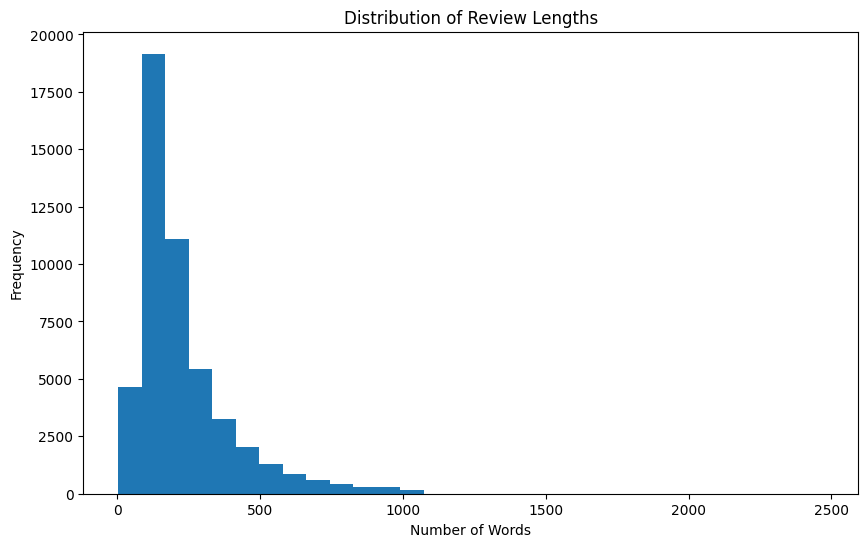

In [221]:
# Plot Histogram of Review Lengths

plt.figure(figsize=(10, 6))
plt.hist(df['review_length'], bins=30)
plt.title('Distribution of Review Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

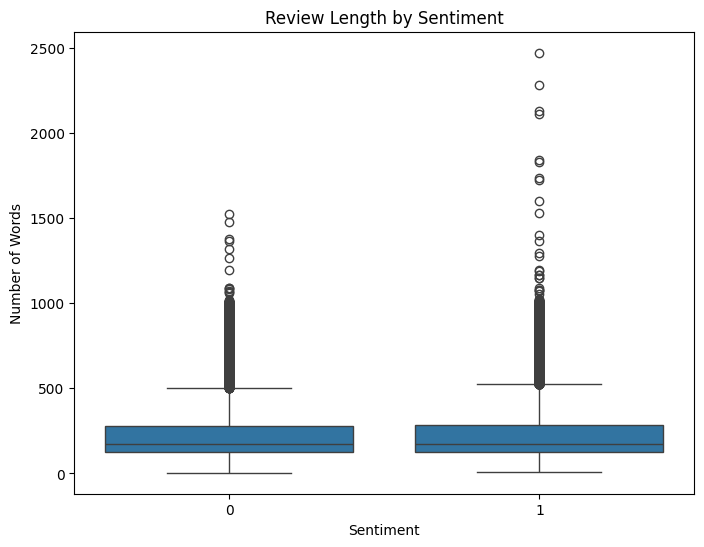

In [222]:
# Plot Boxplot of Review Length by Sentiment

plt.figure(figsize=(8, 6))
sns.boxplot(x='sentiment', y='review_length', data=df)
plt.title('Review Length by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Words')
plt.show()

In [223]:
# Perform Word Frequency Analysis

all_words = ' '.join(X_train_clean)
word_list = all_words.split()

word_freq = pd.Series(word_list).value_counts().head(20)
print(word_freq)

br           80052
movie        68564
film         62435
one          36938
like         27657
time         20341
good         20057
character    19322
even         17027
get          16951
story        16864
would        16636
make         16360
see          16202
really       15785
scene        14424
well         13148
much         13058
great        12573
also         12396
Name: count, dtype: int64


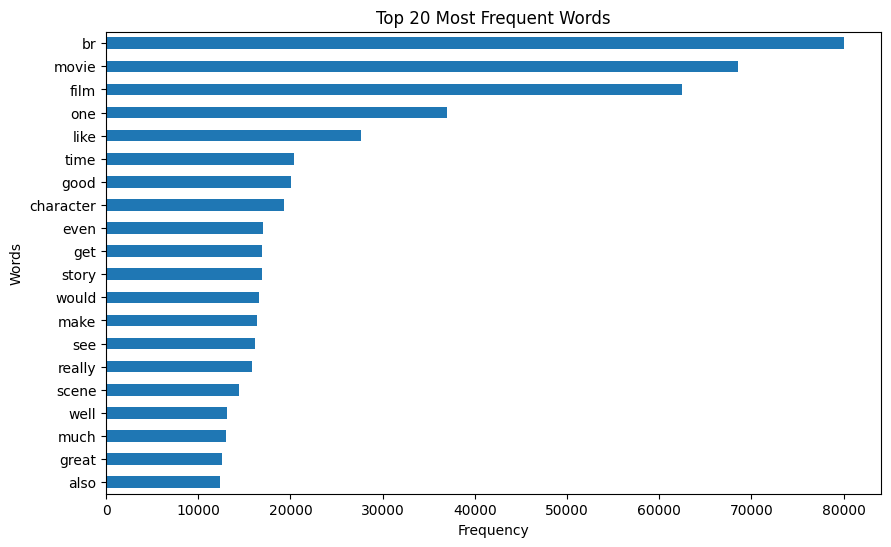

In [224]:
# Plot Most Frequent Words

plt.figure(figsize=(10, 6))
word_freq.sort_values().plot(kind='barh')
plt.title('Top 20 Most Frequent Words')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()

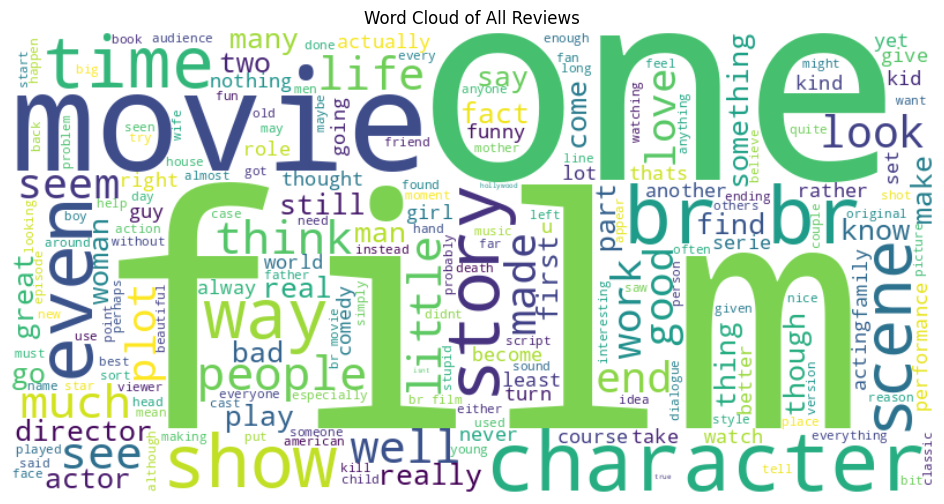

In [225]:
# Plot Word Cloud for All Reviews

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of All Reviews')
plt.show()

In [226]:
# Identify Top-20 Positive Review Words and Top-20 Negative Review Words

positive_reviews = ' '.join(X_train_clean[y_train == 1])
negative_reviews = ' '.join(X_train_clean[y_train == 0])

positive_freq = pd.Series(positive_reviews.split()).value_counts().head(20)
negative_freq = pd.Series(negative_reviews.split()).value_counts().head(20)

print("Top 20 Positive Review Words:")
print(positive_freq)

print("\nTop 20 Negative Review Words:")
print(negative_freq)

Top 20 Positive Review Words:
br           39014
film         33311
movie        30020
one          19130
like         12257
time         10582
good         10139
character     9611
story         9581
great         8968
see           8764
well          7821
get           7756
make          7670
also          7483
really        7424
would         7239
scene         6790
even          6648
show          6454
Name: count, dtype: int64

Top 20 Negative Review Words:
br           41038
movie        38544
film         29124
one          17808
like         15400
even         10379
good          9918
time          9759
bad           9712
character     9711
would         9397
get           9195
make          8690
really        8361
scene         7634
see           7438
story         7283
dont          7100
much          6787
people        6402
Name: count, dtype: int64


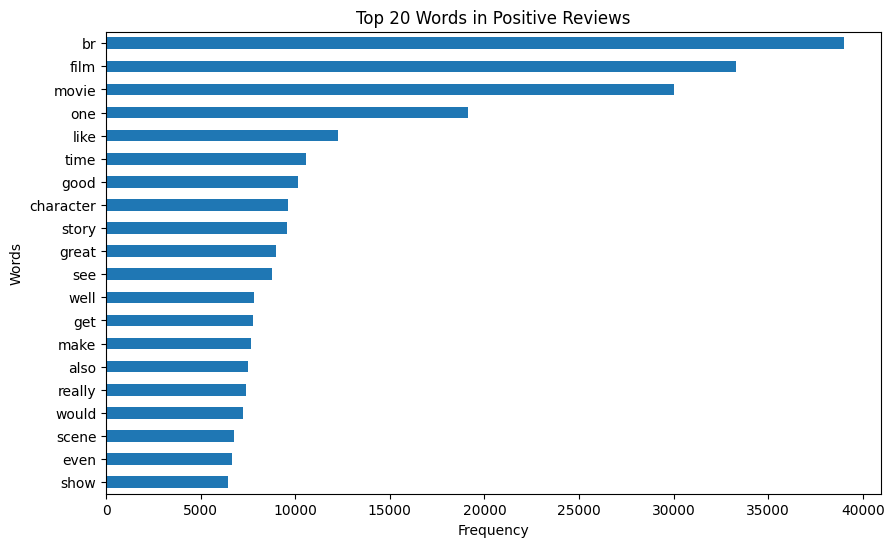

In [227]:
# Plot Top-20 Positive Words

plt.figure(figsize=(10, 6))
positive_freq.sort_values().plot(kind='barh')
plt.title('Top 20 Words in Positive Reviews')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()

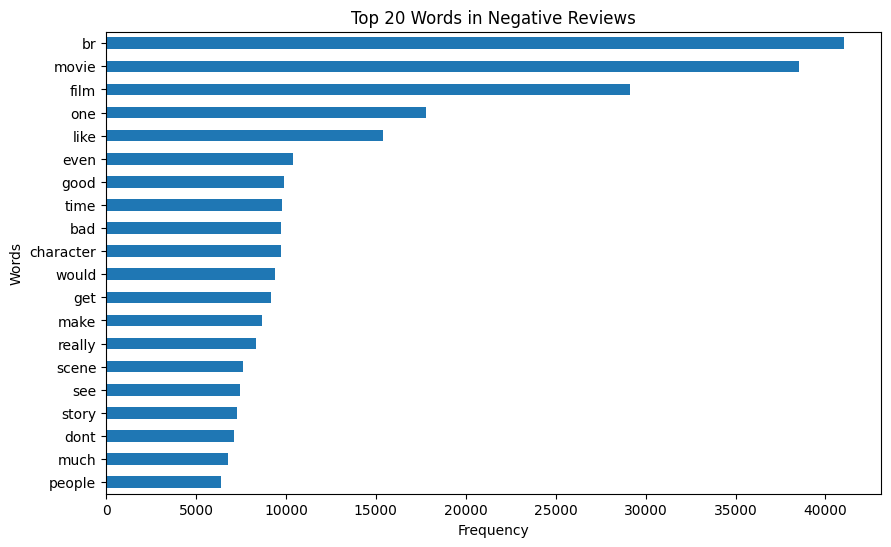

In [228]:
# Plot Top-20 Negative Words

plt.figure(figsize=(10, 6))
negative_freq.sort_values().plot(kind='barh')
plt.title('Top 20 Words in Negative Reviews')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()

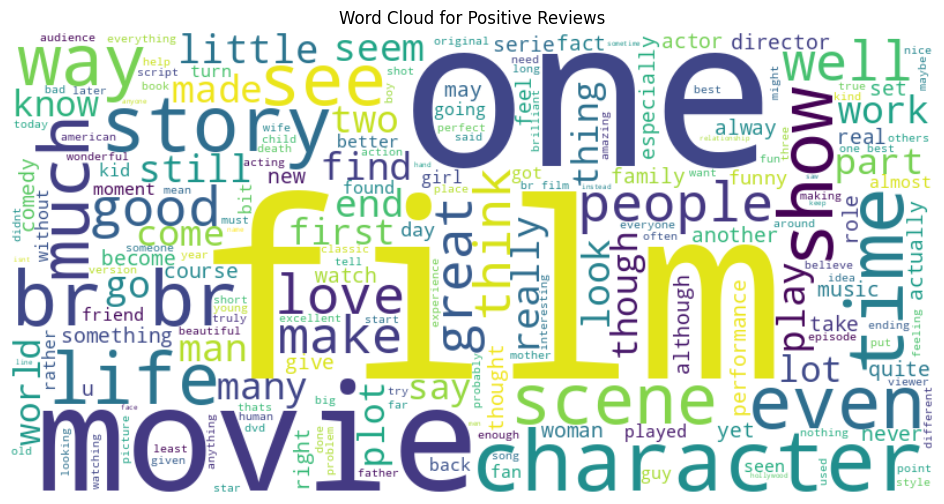

In [229]:
# Plot Word Cloud for Positive Reviews

wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(positive_reviews)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Positive Reviews')
plt.show()

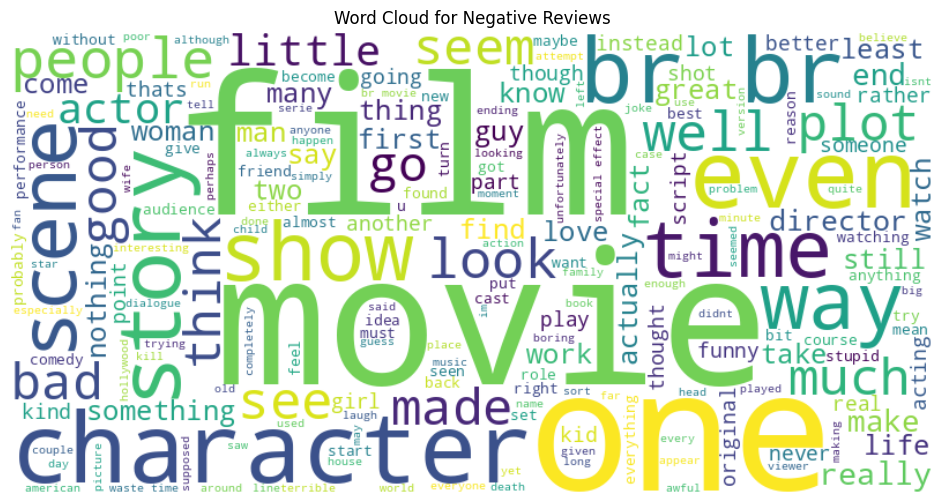

In [230]:
# Plot Word Cloud for Negative Reviews

wordcloud_neg = WordCloud(width=800, height=400, background_color='white').generate(negative_reviews)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Negative Reviews')
plt.show()

In [231]:
# Show IDF Scores for First 50 Keywords Using Unigram Model

idf_df = pd.DataFrame({
    'keyword': tfidf_uni.get_feature_names_out(),
    'idf_score': tfidf_uni.idf_
})

idf_first_50 = idf_df.head(50)
print(idf_first_50)

                       keyword  idf_score
0                           aa   9.152140
1                          aaa   8.969819
2   aaaaaaaaaaaahhhhhhhhhhhhhh  10.761578
3                  aaaaaaaargh  10.761578
4                     aaaaaaah  10.761578
5                       aaaaah  10.356113
6                     aaaaargh  10.761578
7      aaaaarrrrrrgggggghhhhhh  10.761578
8                       aaaaaw  10.761578
9                   aaaahhhhhh  10.761578
10                 aaaahhhhhhh  10.761578
11                      aaaand  10.761578
12                       aaagh  10.761578
13                        aaah  10.356113
14                     aaahthe  10.761578
15                      aaargh   9.845288
16                  aaarrrghim  10.761578
17                         aab  10.761578
18                      aachen  10.356113
19                       aadha  10.761578
20                 aadmittedly  10.761578
21                         aag   9.056830
22                        aage  10

# QUESTION 1 - E

Train the dataset using Logistic Regression, Random Forest and ANN (at least
two hidden layers) classifiers.   

In [232]:
# Train Logistic Regression on Unigram Model

lr_uni = LogisticRegression(max_iter=1000, random_state=42)

lr_uni.fit(X_train_uni, y_train)

y_pred_lr_uni = lr_uni.predict(X_test_uni)
y_prob_lr_uni = lr_uni.predict_proba(X_test_uni)[:, 1]

In [233]:
# Evaluate Logistic Regression on Unigram Model

print("Logistic Regression - Unigram TF-IDF")
print("Accuracy:", accuracy_score(y_test, y_pred_lr_uni))
print("Precision:", precision_score(y_test, y_pred_lr_uni))
print("Recall:", recall_score(y_test, y_pred_lr_uni))
print("F1-score:", f1_score(y_test, y_pred_lr_uni))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr_uni))

Logistic Regression - Unigram TF-IDF
Accuracy: 0.8871932773109243
Precision: 0.8785817087531074
Recall: 0.899531145344943
F1-score: 0.8889330156208631
ROC-AUC: 0.9567713296327529


In [234]:
# Classification Report

print(classification_report(y_test, y_pred_lr_uni))

              precision    recall  f1-score   support

           0       0.90      0.87      0.89      7410
           1       0.88      0.90      0.89      7465

    accuracy                           0.89     14875
   macro avg       0.89      0.89      0.89     14875
weighted avg       0.89      0.89      0.89     14875



In [235]:
# Confusion Matrix

cm_lr_uni = confusion_matrix(y_test, y_pred_lr_uni)
print(cm_lr_uni)

[[6482  928]
 [ 750 6715]]


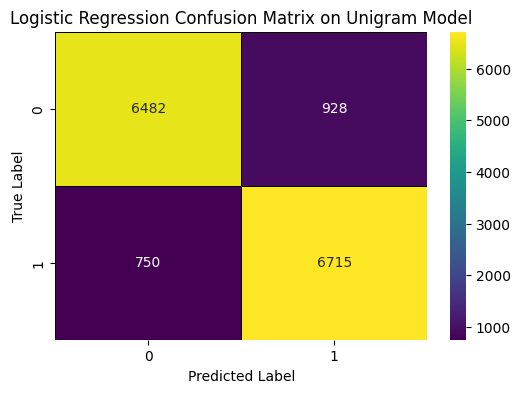

In [236]:
# Plot Confusion Matrix Heatmap

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_lr_uni,
    annot=True,
    fmt='d',
    cmap='viridis',
    linewidths=0.5,
    linecolor='black'
)
plt.title('Logistic Regression Confusion Matrix on Unigram Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [237]:
# Logistic Regression - Unigram + Bigram TF-IDF

lr_bi = LogisticRegression(max_iter=1000, random_state=42)

lr_bi.fit(X_train_bi, y_train)

y_pred_lr_bi = lr_bi.predict(X_test_bi)
y_prob_lr_bi = lr_bi.predict_proba(X_test_bi)[:, 1]

print("Bigram Logistic Regression model completed.")

Bigram Logistic Regression model completed.


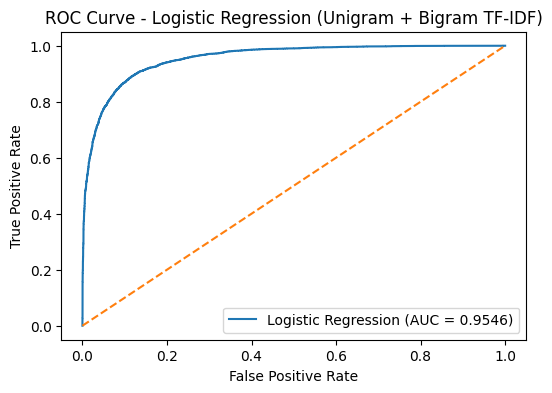

In [238]:
# ROC Curve

fpr_lr_bi, tpr_lr_bi, thresholds_lr_bi = roc_curve(y_test, y_prob_lr_bi)

plt.figure(figsize=(6, 4))
plt.plot(fpr_lr_bi, tpr_lr_bi, label='Logistic Regression (AUC = {:.4f})'.format(roc_auc_score(y_test, y_prob_lr_bi)))
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('ROC Curve - Logistic Regression (Unigram + Bigram TF-IDF)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [239]:
# Train Random Forest on Unigram TF-IDF Model

rf_uni = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_uni.fit(X_train_uni, y_train)

y_pred_rf_uni = rf_uni.predict(X_test_uni)
y_prob_rf_uni = rf_uni.predict_proba(X_test_uni)[:, 1]

In [240]:
# Evaluate Random Forest on Unigram TF-IDF Model

print("Random Forest - Unigram TF-IDF")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_uni))
print("Precision:", precision_score(y_test, y_pred_rf_uni))
print("Recall:", recall_score(y_test, y_pred_rf_uni))
print("F1-score:", f1_score(y_test, y_pred_rf_uni))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf_uni))

Random Forest - Unigram TF-IDF
Accuracy: 0.8504201680672269
Precision: 0.8603851444291609
Recall: 0.8379102478231748
F1-score: 0.8489989820156091
ROC-AUC: 0.9256850366939555


In [241]:
# Print Classification Report

print(classification_report(y_test, y_pred_rf_uni))

              precision    recall  f1-score   support

           0       0.84      0.86      0.85      7410
           1       0.86      0.84      0.85      7465

    accuracy                           0.85     14875
   macro avg       0.85      0.85      0.85     14875
weighted avg       0.85      0.85      0.85     14875



In [242]:
# Generate COnfusion Matrix

cm_rf_uni = confusion_matrix(y_test, y_pred_rf_uni)
print(cm_rf_uni)

[[6395 1015]
 [1210 6255]]


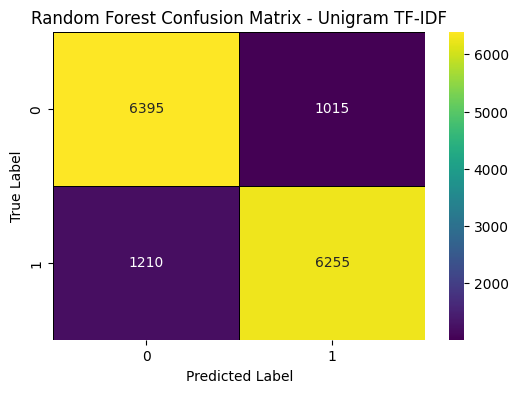

In [243]:
# Plot Confusion Matrix HEatmap

plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf_uni, annot=True, fmt='d', cmap='viridis', linewidths=0.5, linecolor='black')
plt.title('Random Forest Confusion Matrix - Unigram TF-IDF')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

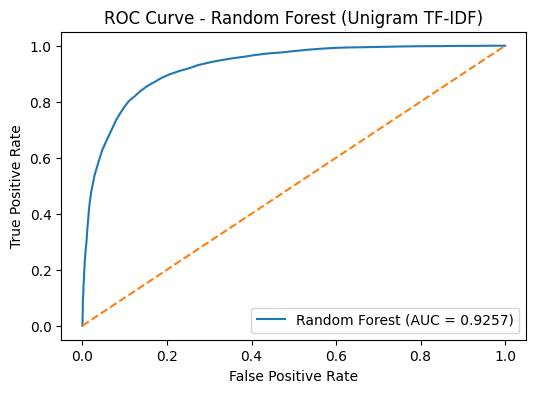

In [244]:
# Plot ROC Curve

fpr_rf_uni, tpr_rf_uni, thresholds_rf_uni = roc_curve(y_test, y_prob_rf_uni)

plt.figure(figsize=(6, 4))
plt.plot(fpr_rf_uni, tpr_rf_uni, label='Random Forest (AUC = {:.4f})'.format(roc_auc_score(y_test, y_prob_rf_uni)))
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('ROC Curve - Random Forest (Unigram TF-IDF)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [ ]:
# Train Random Forest on Unigram and Bigram TF-IDF Models

rf_bi = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_bi.fit(X_train_bi, y_train)

y_pred_rf_bi = rf_bi.predict(X_test_bi)
y_prob_rf_bi = rf_bi.predict_proba(X_test_bi)[:, 1]

In [ ]:
# Evaluate Random Forest on Unigram and Bigram TF-IDF Models

print("Random Forest - Unigram + Bigram TF-IDF")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_bi))
print("Precision:", precision_score(y_test, y_pred_rf_bi))
print("Recall:", recall_score(y_test, y_pred_rf_bi))
print("F1-score:", f1_score(y_test, y_pred_rf_bi))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf_bi))

Random Forest - Unigram + Bigram TF-IDF
Accuracy: 0.8526386554621849
Precision: 0.8642077635032464
Recall: 0.8380442062960483
F1-score: 0.8509249183895539
ROC-AUC: 0.930323534117379


In [ ]:
# Display Classification Report for Random Forest on Unigram and Bigram TF-IDF Models

print(classification_report(y_test, y_pred_rf_bi))

              precision    recall  f1-score   support

           0       0.84      0.87      0.85      7410
           1       0.86      0.84      0.85      7465

    accuracy                           0.85     14875
   macro avg       0.85      0.85      0.85     14875
weighted avg       0.85      0.85      0.85     14875



In [ ]:
# Display Confusion Matrix

cm_rf_bi = confusion_matrix(y_test, y_pred_rf_bi)
print(cm_rf_bi)

[[6427  983]
 [1209 6256]]


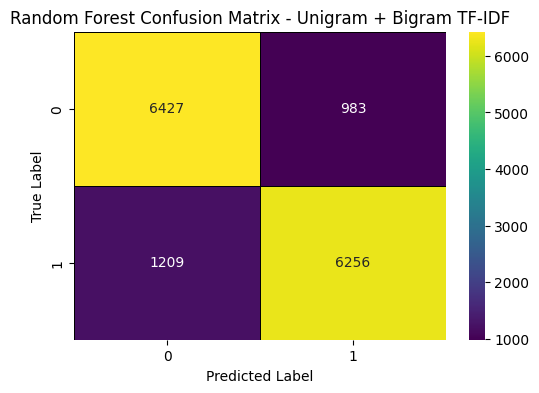

In [ ]:
# Plot Confusion Matrix for Random Forest on Unigram and Bigram TF-IDF Models

plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf_bi, annot=True, fmt='d', cmap='viridis', linewidths=0.5, linecolor='black')
plt.title('Random Forest Confusion Matrix - Unigram + Bigram TF-IDF')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

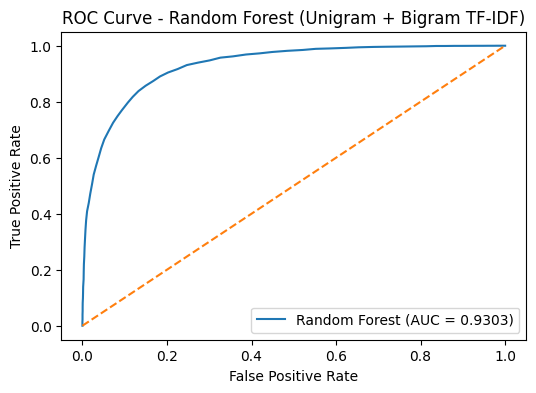

In [ ]:
# Plot ROC Curve

fpr_rf_bi, tpr_rf_bi, thresholds_rf_bi = roc_curve(y_test, y_prob_rf_bi)

plt.figure(figsize=(6, 4))
plt.plot(fpr_rf_bi, tpr_rf_bi, label='Random Forest (AUC = {:.4f})'.format(roc_auc_score(y_test, y_prob_rf_bi)))
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('ROC Curve - Random Forest (Unigram + Bigram TF-IDF)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [ ]:
# Train ANN on Unigram TF-IDF Model

ann_uni = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    max_iter=20,
    random_state=42
)

ann_uni.fit(X_train_uni, y_train)

y_pred_ann_uni = ann_uni.predict(X_test_uni)
y_prob_ann_uni = ann_uni.predict_proba(X_test_uni)[:, 1]

In [ ]:
# Evaluate ANN on Unigram TF-IDF Model

print("ANN - Unigram TF-IDF")
print("Accuracy:", accuracy_score(y_test, y_pred_ann_uni))
print("Precision:", precision_score(y_test, y_pred_ann_uni))
print("Recall:", recall_score(y_test, y_pred_ann_uni))
print("F1-score:", f1_score(y_test, y_pred_ann_uni))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_ann_uni))

ANN - Unigram TF-IDF
Accuracy: 0.8790588235294118
Precision: 0.8776326312983205
Recall: 0.8819825853985265
F1-score: 0.8798022315761341
ROC-AUC: 0.9498921372161405


In [ ]:
# Display Confusion Matrix

cm_ann_uni = confusion_matrix(y_test, y_pred_ann_uni)
print(cm_ann_uni)

[[6492  918]
 [ 881 6584]]


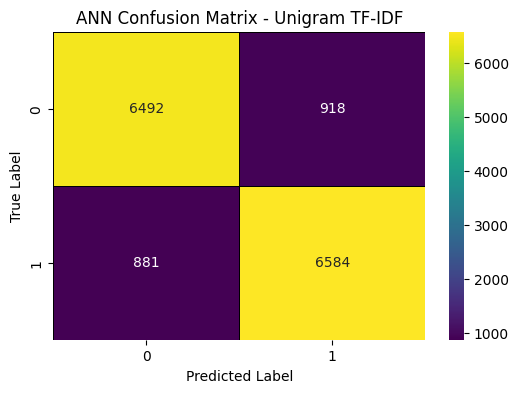

In [ ]:
# Plot Confusion MAtrix Heatmap

plt.figure(figsize=(6, 4))
sns.heatmap(cm_ann_uni, annot=True, fmt='d', cmap='viridis', linewidths=0.5, linecolor='black')
plt.title('ANN Confusion Matrix - Unigram TF-IDF')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

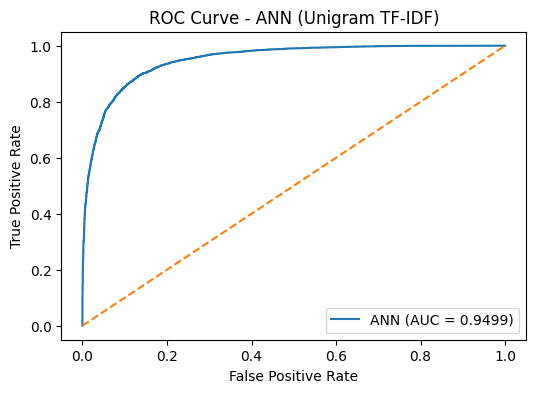

In [ ]:
# Plot ROC Curve

fpr_ann_uni, tpr_ann_uni, thresholds_ann_uni = roc_curve(y_test, y_prob_ann_uni)

plt.figure(figsize=(6, 4))
plt.plot(fpr_ann_uni, tpr_ann_uni, label='ANN (AUC = {:.4f})'.format(roc_auc_score(y_test, y_prob_ann_uni)))
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('ROC Curve - ANN (Unigram TF-IDF)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

# QUESTION 1 - F

Perform K-NN classification: Fit and test the model for different values for K
(from 1 to 25) using a for loop and record and plot the KNN’s testing accuracy in a variable (scores).     

Compare:
*   Euclidean distance
*   Cosine similarity

Plot: Validation accuracy vs K

In [ ]:
# Generate Variables for KNN Accuracy Scores

k_values = range(1, 26)

scores_euclidean = []
scores_cosine = []

In [ ]:
# Train and Evaluate KNN Models for K = 1 to 25 Using Euclidean Distance and Cosine Similarity

for k in k_values:
    knn_euclidean = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn_euclidean.fit(X_train_uni, y_train)
    y_pred_euclidean = knn_euclidean.predict(X_test_uni)
    scores_euclidean.append(accuracy_score(y_test, y_pred_euclidean))

    knn_cosine = KNeighborsClassifier(n_neighbors=k, metric='cosine', algorithm='brute')
    knn_cosine.fit(X_train_uni, y_train)
    y_pred_cosine = knn_cosine.predict(X_test_uni)
    scores_cosine.append(accuracy_score(y_test, y_pred_cosine))

In [ ]:
# Display KNN Testing Accuracy Results

knn_results = pd.DataFrame({
    'K': list(k_values),
    'Euclidean_Accuracy': scores_euclidean,
    'Cosine_Accuracy': scores_cosine
})

print(knn_results)

In [ ]:
# Plot Testing Accuracy vs K for Euclidean Distance and Cosine Similarity

plt.figure(figsize=(10, 6))
plt.plot(k_values, scores_euclidean, marker='o', label='Euclidean Distance')
plt.plot(k_values, scores_cosine, marker='s', label='Cosine Similarity')
plt.title('KNN Testing Accuracy vs K')
plt.xlabel('Value of K')
plt.ylabel('Testing Accuracy')
plt.xticks(range(1, 26))
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Identify Best K for Each Distance Measure

best_k_euclidean = k_values[np.argmax(scores_euclidean)]
best_score_euclidean = max(scores_euclidean)

best_k_cosine = k_values[np.argmax(scores_cosine)]
best_score_cosine = max(scores_cosine)

print("Best Euclidean K:", best_k_euclidean)
print("Best Euclidean Accuracy:", best_score_euclidean)

print("Best Cosine K:", best_k_cosine)
print("Best Cosine Accuracy:", best_score_cosine)

# QUESTION 1 - G

Compare the performances of different classifiers (test set) based on different
feature representations:  

Model Evaluation and Statistical Analysis: Classification Metrics, Accuracy,
Precision, Recall, F1-score and ROC-AUC

Visualizations: Confusion matrices   and   ROC curves

In [ ]:
# Create Summary Table for Model Performance Comparison

model_results = pd.DataFrame([
    {
        'Model': 'Logistic Regression',
        'Features': 'Unigram TF-IDF',
        'Accuracy': accuracy_score(y_test, y_pred_lr_uni),
        'Precision': precision_score(y_test, y_pred_lr_uni),
        'Recall': recall_score(y_test, y_pred_lr_uni),
        'F1-score': f1_score(y_test, y_pred_lr_uni),
        'ROC-AUC': roc_auc_score(y_test, y_prob_lr_uni)
    },
    {
        'Model': 'Logistic Regression',
        'Features': 'Unigram + Bigram TF-IDF',
        'Accuracy': accuracy_score(y_test, y_pred_lr_bi),
        'Precision': precision_score(y_test, y_pred_lr_bi),
        'Recall': recall_score(y_test, y_pred_lr_bi),
        'F1-score': f1_score(y_test, y_pred_lr_bi),
        'ROC-AUC': roc_auc_score(y_test, y_prob_lr_bi)
    },
    {
        'Model': 'Random Forest',
        'Features': 'Unigram + Bigram TF-IDF',
        'Accuracy': accuracy_score(y_test, y_pred_rf_bi),
        'Precision': precision_score(y_test, y_pred_rf_bi),
        'Recall': recall_score(y_test, y_pred_rf_bi),
        'F1-score': f1_score(y_test, y_pred_rf_bi),
        'ROC-AUC': roc_auc_score(y_test, y_prob_rf_bi)
    },
    {
        'Model': 'ANN',
        'Features': 'Unigram TF-IDF',
        'Accuracy': accuracy_score(y_test, y_pred_ann_uni),
        'Precision': precision_score(y_test, y_pred_ann_uni),
        'Recall': recall_score(y_test, y_pred_ann_uni),
        'F1-score': f1_score(y_test, y_pred_ann_uni),
        'ROC-AUC': roc_auc_score(y_test, y_prob_ann_uni)
    }
])

print(model_results)

In [ ]:
# Summary Table

model_results_rounded = model_results.copy()

for col in ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']:
    model_results_rounded[col] = model_results_rounded[col].round(4)

print(model_results_rounded)

In [ ]:
# Identify Best Performing Model by Accuracy and ROC-AUC

best_accuracy_row = model_results_rounded.loc[model_results_rounded['Accuracy'].idxmax()]
best_rocauc_row = model_results_rounded.loc[model_results_rounded['ROC-AUC'].idxmax()]

print("Best Model by Accuracy:")
print(best_accuracy_row)

print("\nBest Model by ROC-AUC:")
print(best_rocauc_row)

In [ ]:
# Display Confusion Matrices for All Models Used in the Comparison

cm_lr_uni = confusion_matrix(y_test, y_pred_lr_uni)
cm_lr_bi = confusion_matrix(y_test, y_pred_lr_bi)
cm_rf_bi = confusion_matrix(y_test, y_pred_rf_bi)
cm_ann_uni = confusion_matrix(y_test, y_pred_ann_uni)

print("Logistic Regression - Unigram TF-IDF")
print(cm_lr_uni)

print("\nLogistic Regression - Unigram + Bigram TF-IDF")
print(cm_lr_bi)

print("\nRandom Forest - Unigram + Bigram TF-IDF")
print(cm_rf_bi)

print("\nANN - Unigram TF-IDF")
print(cm_ann_uni)

In [ ]:
# Plot Confusion Matrix for Logistic Regression on Unigram TF-IDF Model

plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr_uni, annot=True, fmt='d', cmap='viridis', linewidths=0.5, linecolor='black')
plt.title('Confusion Matrix - Logistic Regression (Unigram TF-IDF)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
# Plot Confusion Matrix for Logistic Regression on Unigram + Bigram TF-IDF Models

plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr_bi, annot=True, fmt='d', cmap='viridis', linewidths=0.5, linecolor='black')
plt.title('Confusion Matrix - Logistic Regression (Unigram + Bigram TF-IDF)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
# Plot Confusion Matrix for Random Forest on Unigram + Bigram TF-IDF

plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf_bi, annot=True, fmt='d', cmap='viridis', linewidths=0.5, linecolor='black')
plt.title('Confusion Matrix - Random Forest (Unigram + Bigram TF-IDF)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
# Plot Confusion Matrix for ANN on Unigram TF-IDF Model

plt.figure(figsize=(6, 4))
sns.heatmap(cm_ann_uni, annot=True, fmt='d', cmap='viridis', linewidths=0.5, linecolor='black')
plt.title('Confusion Matrix - ANN (Unigram TF-IDF)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
# Plot ROC Curves for All Models

fpr_lr_uni, tpr_lr_uni, _ = roc_curve(y_test, y_prob_lr_uni)
fpr_lr_bi, tpr_lr_bi, _ = roc_curve(y_test, y_prob_lr_bi)
fpr_rf_bi, tpr_rf_bi, _ = roc_curve(y_test, y_prob_rf_bi)
fpr_ann_uni, tpr_ann_uni, _ = roc_curve(y_test, y_prob_ann_uni)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr_uni, tpr_lr_uni, label='Logistic Regression - Unigram (AUC = {:.4f})'.format(roc_auc_score(y_test, y_prob_lr_uni)))
plt.plot(fpr_lr_bi, tpr_lr_bi, label='Logistic Regression - Unigram + Bigram (AUC = {:.4f})'.format(roc_auc_score(y_test, y_prob_lr_bi)))
plt.plot(fpr_rf_bi, tpr_rf_bi, label='Random Forest - Unigram + Bigram (AUC = {:.4f})'.format(roc_auc_score(y_test, y_prob_rf_bi)))
plt.plot(fpr_ann_uni, tpr_ann_uni, label='ANN - Unigram (AUC = {:.4f})'.format(roc_auc_score(y_test, y_prob_ann_uni)))
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('ROC Curve Comparison of Classifiers')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

# QUESTION 2 - A

Load the train, test and validation datasets from csv files to pandas
dataframe.

In [ ]:
# Import Pandas

import pandas as pd

In [ ]:
# Load Training, Validation, and Test Datasets

train_df = pd.read_csv('train.txt', sep=';', header=None, names=['text', 'emotion'])
validation_df = pd.read_csv('val.txt', sep=';', header=None, names=['text', 'emotion'])
test_df = pd.read_csv('test.txt', sep=';', header=None, names=['text', 'emotion'])

In [ ]:
# Display First Five Rows of Each Dataset

print("Training Dataset")
print(train_df.head())

print("\nValidation Dataset")
print(validation_df.head())

print("\nTest Dataset")
print(test_df.head())

In [ ]:
# Display Dataset Shapes

print("Training Set Shape:", train_df.shape)
print("Validation Set Shape:", validation_df.shape)
print("Test Set Shape:", test_df.shape)

In [ ]:
# Print One Raw Line from the Training File

with open('train.txt', 'r', encoding='utf-8') as f:
    for i in range(5):
        print(f.readline())

# QUESTION 2 - B

Display: dataset dimensions, class distributions, missing values, and
duplicate records. Perform exploratory analysis:

*    average sentence length,  
*    most frequent words,  
*   class imbalance visualization,  
*   word clouds for each emotion category.


In [ ]:
# Display Dataset Dimensions

print("Training Set Shape:", train_df.shape)
print("Validation Set Shape:", validation_df.shape)
print("Test Set Shape:", test_df.shape)

In [ ]:
# Print Class Distribution for Each Dataset

print("Training Set Class Distribution")
print(train_df['emotion'].value_counts())

print("\nValidation Set Class Distribution")
print(validation_df['emotion'].value_counts())

print("\nTest Set Class Distribution")
print(test_df['emotion'].value_counts())


In [ ]:
# Display Missing Values for Each Dataset

print("Missing Values in Training Set")
print(train_df.isnull().sum())

print("\nMissing Values in Validation Set")
print(validation_df.isnull().sum())

print("\nMissing Values in Test Set")
print(test_df.isnull().sum())

In [ ]:
# Print Duplicate Records for Each Dataset

print("Duplicate Records in Training Set:", train_df.duplicated().sum())
print("Duplicate Records in Validation Set:", validation_df.duplicated().sum())
print("Duplicate Records in Test Set:", test_df.duplicated().sum())

In [ ]:
# Calculate Average Sentence Length for Each Dataset

train_df['sentence_length'] = train_df['text'].apply(lambda x: len(str(x).split()))
validation_df['sentence_length'] = validation_df['text'].apply(lambda x: len(str(x).split()))
test_df['sentence_length'] = test_df['text'].apply(lambda x: len(str(x).split()))

print("Average Sentence Length in Training Set:", train_df['sentence_length'].mean())
print("Average Sentence Length in Validation Set:", validation_df['sentence_length'].mean())
print("Average Sentence Length in Test Set:", test_df['sentence_length'].mean())

In [ ]:
# Plot Histogram SHowing Sentence Length Distribution for Training Set

plt.figure(figsize=(10, 6))
plt.hist(train_df['sentence_length'], bins=30)
plt.title('Sentence Length Distribution - Training Set')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Combine All Training Text into One String

all_train_text = ' '.join(train_df['text'])
all_train_words = all_train_text.split()

word_freq_train = pd.Series(all_train_words).value_counts().head(20)
print(word_freq_train)

In [ ]:
# Plot Most Frequent Words in Training Set

plt.figure(figsize=(10, 6))
word_freq_train.sort_values().plot(kind='barh')
plt.title('Top 20 Most Frequent Words in Training Set')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()

In [ ]:
# Plot Emotion Class Distribution in Training Set

plt.figure(figsize=(10, 6))
train_df['emotion'].value_counts().plot(kind='bar')
plt.title('Emotion Class Distribution - Training Set')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Display Unique Emotion Categories

print(train_df['emotion'].unique())

In [ ]:
# Create Word Cloud for Each Emotion Category

emotion_list = train_df['emotion'].unique()

for emotion in emotion_list:
    emotion_text = ' '.join(train_df[train_df['emotion'] == emotion]['text'])

    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(emotion_text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud for Emotion: ' + emotion)
    plt.show()

# QUESTION 2 - C
Perform the necessary pre-text processing (similar to Question 1) for
vocabulary generation.

In [ ]:
## Generate Preprocessing Functions

# Create Stopwords Set and Lemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [ ]:
# Define Text Preprocessing Function

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)

In [ ]:
# Apply Preprocessing to Training, Validation, and Test Datasets

train_df['clean_text'] = train_df['text'].apply(preprocess_text)
validation_df['clean_text'] = validation_df['text'].apply(preprocess_text)
test_df['clean_text'] = test_df['text'].apply(preprocess_text)

In [ ]:
# Display Original and Cleaned Text Samples

print("Original Text:")
print(train_df['text'].head())

print("\nCleaned Text:")
print(train_df['clean_text'].head())

# QUESTION 2 - D

Generate a vocabulary using the top 500 most frequent terms from the
training corpus only.

In [ ]:
# Combine All Cleaned Training Text into One String

all_train_clean_text = ' '.join(train_df['clean_text'])
all_train_tokens = all_train_clean_text.split()

In [ ]:
# Count Word Frequencies in the Training Corpus

train_word_freq = pd.Series(all_train_tokens).value_counts()
print(train_word_freq.head(20))

In [ ]:
# Select the Top 500 Most Frequent Terms

top_500_vocab = train_word_freq.head(500).index.tolist()

print("Vocabulary Size:", len(top_500_vocab))
print(top_500_vocab[:50])

In [ ]:
# Vocabulary List to DataFrame for Print

vocab_df = pd.DataFrame(top_500_vocab, columns=['term'])
print(vocab_df.head(20))

# QUESTION 2 - E

Construct multiple feature representations.

1. Bag-of-Words (BoW)
2. TF-IDF
3. Word Embedding Representation

(Use pre-trained embeddings):
Word2Vec  Or  GloVe  
Represent each document using average word embeddings

In [ ]:
# Create Bag-of-Words Representation Using Top 500 Vocabulary Terms

bow_vectorizer = CountVectorizer(vocabulary=top_500_vocab)

X_train_bow = bow_vectorizer.fit_transform(train_df['clean_text'])
X_validation_bow = bow_vectorizer.transform(validation_df['clean_text'])
X_test_bow = bow_vectorizer.transform(test_df['clean_text'])

print("BoW Training Shape:", X_train_bow.shape)
print("BoW Validation Shape:", X_validation_bow.shape)
print("BoW Test Shape:", X_test_bow.shape)

In [ ]:
# Install Gensim

!pip install gensim

In [ ]:
# Import Gensim

import gensim.downloader as api

In [ ]:
# Create TF-IDF Representation Using Top 500 Vocabulary Terms

tfidf_vectorizer_q2 = TfidfVectorizer(vocabulary=top_500_vocab)

X_train_tfidf = tfidf_vectorizer_q2.fit_transform(train_df['clean_text'])
X_validation_tfidf = tfidf_vectorizer_q2.transform(validation_df['clean_text'])
X_test_tfidf = tfidf_vectorizer_q2.transform(test_df['clean_text'])

print("TF-IDF Training Shape:", X_train_tfidf.shape)
print("TF-IDF Validation Shape:", X_validation_tfidf.shape)
print("TF-IDF Test Shape:", X_test_tfidf.shape)

In [ ]:
# Load Pre-trained GloVe Embeddings

glove_model = api.load('glove-wiki-gigaword-100')
print("Pre-trained GloVe model loaded successfully.")

In [ ]:
# Define Function to Compute Average Word Embeddings for Each Document

def document_embedding(text, embedding_model, embedding_dim=100):
    words = text.split()
    word_vectors = []

    for word in words:
        if word in embedding_model:
            word_vectors.append(embedding_model[word])

    if len(word_vectors) == 0:
        return np.zeros(embedding_dim)
    else:
        return np.mean(word_vectors, axis=0)

In [ ]:
# Create Average Word Embedding Features for Training, Validation, and Test Sets

X_train_embed = np.array([document_embedding(text, glove_model) for text in train_df['clean_text']])
X_validation_embed = np.array([document_embedding(text, glove_model) for text in validation_df['clean_text']])
X_test_embed = np.array([document_embedding(text, glove_model) for text in test_df['clean_text']])

print("Embedding Training Shape:", X_train_embed.shape)
print("Embedding Validation Shape:", X_validation_embed.shape)
print("Embedding Test Shape:", X_test_embed.shape)

In [ ]:
# Print Average Word Embeddings Using GloVe

print(X_train_embed[0][:10])

# QUESTION 2 - F

Train the dataset using Decision Tree, Random Forest, and ANN.
Hyperparameter Tuning: Use: GridSearchCV Or RandomizedSearchCV for
at least two classifiers.

In [ ]:
# Import Model Training and Libraries for Tuning

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
# DECISION TREE

# Define Target Variables

y_train_q2 = train_df['emotion']
y_validation_q2 = validation_df['emotion']
y_test_q2 = test_df['emotion']

In [ ]:
# Define Hyperparameter Grid for Decision Tree

dt_param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10]
}

In [ ]:
# Perform Grid Search for Decision Tree Using TF-IDF Features

dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=dt_param_grid,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1
)

dt_grid.fit(X_train_tfidf, y_train_q2)

best_dt_model = dt_grid.best_estimator_

print("Best Decision Tree Parameters:", dt_grid.best_params_)
print("Best Decision Tree CV Score:", dt_grid.best_score_)

In [ ]:
# Evaluate Best Decision Tree Model on Validation Set

y_pred_dt_val = best_dt_model.predict(X_validation_tfidf)

print("Decision Tree Validation Accuracy:", accuracy_score(y_validation_q2, y_pred_dt_val))
print(classification_report(y_validation_q2, y_pred_dt_val))

In [ ]:
# RANDOM FOREST

# Define Hyperparameter Distribution for Random Forest

rf_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [ ]:
# Perform Randomized Search for Random Forest Using TF-IDF Features

rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=10,
    scoring='f1_macro',
    cv=3,
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train_tfidf, y_train_q2)

best_rf_model = rf_random.best_estimator_

print("Best Random Forest Parameters:", rf_random.best_params_)
print("Best Random Forest CV Score:", rf_random.best_score_)

In [ ]:
# Evaluate Best Random Forest Model on Validation Set

y_pred_rf_val = best_rf_model.predict(X_validation_tfidf)

print("Random Forest Validation Accuracy:", accuracy_score(y_validation_q2, y_pred_rf_val))
print(classification_report(y_validation_q2, y_pred_rf_val))

In [ ]:
# ARTIFICIAL NEURAL NETWORK

# Train ANN Model Using Average Word Embedding Features

ann_model_q2 = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    max_iter=30,
    random_state=42
)

ann_model_q2.fit(X_train_embed, y_train_q2)

In [ ]:
# Evaluate ANN Model on Validation Set

y_pred_ann_val = ann_model_q2.predict(X_validation_embed)

print("ANN Validation Accuracy:", accuracy_score(y_validation_q2, y_pred_ann_val))
print(classification_report(y_validation_q2, y_pred_ann_val))

# QUESTION 2 - G

Evaluate all models on the test dataset. Required metrics
• Accuracy, Precision, Recall, Macro F1-score
• Confusion Matrix

In [ ]:
# Import Evaluation Metrics for Multi-Class Classification

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [ ]:
# Generate Test Predictions for All Models

y_pred_dt_test = best_dt_model.predict(X_test_tfidf)
y_pred_rf_test = best_rf_model.predict(X_test_tfidf)
y_pred_ann_test = ann_model_q2.predict(X_test_embed)

In [ ]:
# Evaluate Decision Tree Model on the Test Set

print("Decision Tree Test Performance")
print("Accuracy:", accuracy_score(y_test_q2, y_pred_dt_test))
print("Precision:", precision_score(y_test_q2, y_pred_dt_test, average='macro'))
print("Recall:", recall_score(y_test_q2, y_pred_dt_test, average='macro'))
print("Macro F1-score:", f1_score(y_test_q2, y_pred_dt_test, average='macro'))

In [ ]:
# Evaluate Random Forest Model on the Test Set

print("Random Forest Test Performance")
print("Accuracy:", accuracy_score(y_test_q2, y_pred_rf_test))
print("Precision:", precision_score(y_test_q2, y_pred_rf_test, average='macro'))
print("Recall:", recall_score(y_test_q2, y_pred_rf_test, average='macro'))
print("Macro F1-score:", f1_score(y_test_q2, y_pred_rf_test, average='macro'))

In [ ]:
# Evaluate ANN Model on the Test Set

print("ANN Test Performance")
print("Accuracy:", accuracy_score(y_test_q2, y_pred_ann_test))
print("Precision:", precision_score(y_test_q2, y_pred_ann_test, average='macro'))
print("Recall:", recall_score(y_test_q2, y_pred_ann_test, average='macro'))
print("Macro F1-score:", f1_score(y_test_q2, y_pred_ann_test, average='macro'))

In [ ]:
# Summary Table for Model Comparison

q2_model_results = pd.DataFrame([
    {
        'Model': 'Decision Tree',
        'Accuracy': accuracy_score(y_test_q2, y_pred_dt_test),
        'Precision': precision_score(y_test_q2, y_pred_dt_test, average='macro'),
        'Recall': recall_score(y_test_q2, y_pred_dt_test, average='macro'),
        'Macro F1-score': f1_score(y_test_q2, y_pred_dt_test, average='macro')
    },
    {
        'Model': 'Random Forest',
        'Accuracy': accuracy_score(y_test_q2, y_pred_rf_test),
        'Precision': precision_score(y_test_q2, y_pred_rf_test, average='macro'),
        'Recall': recall_score(y_test_q2, y_pred_rf_test, average='macro'),
        'Macro F1-score': f1_score(y_test_q2, y_pred_rf_test, average='macro')
    },
    {
        'Model': 'ANN',
        'Accuracy': accuracy_score(y_test_q2, y_pred_ann_test),
        'Precision': precision_score(y_test_q2, y_pred_ann_test, average='macro'),
        'Recall': recall_score(y_test_q2, y_pred_ann_test, average='macro'),
        'Macro F1-score': f1_score(y_test_q2, y_pred_ann_test, average='macro')
    }
])

print(q2_model_results.round(4))

In [ ]:
# Create Confusion Matrix for Decision Tree Model

cm_dt_test = confusion_matrix(y_test_q2, y_pred_dt_test)
print(cm_dt_test)

In [ ]:
# Plot Confusion Matrix for Decision Tree Model

plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt_test, annot=True, fmt='d', cmap='viridis', linewidths=0.5, linecolor='black')
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
# Create Confusion Matrix for Random Forest Model

cm_rf_test = confusion_matrix(y_test_q2, y_pred_rf_test)
print(cm_rf_test)

In [ ]:
# Plot Confusion Matrix for Random Forest Model

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf_test, annot=True, fmt='d', cmap='viridis', linewidths=0.5, linecolor='black')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
# Create Confusion Matrix for ANN Model

cm_ann_test = confusion_matrix(y_test_q2, y_pred_ann_test)
print(cm_ann_test)

In [ ]:
# Plot Confusion Matrix for ANN Model

plt.figure(figsize=(8, 6))
sns.heatmap(cm_ann_test, annot=True, fmt='d', cmap='viridis', linewidths=0.5, linecolor='black')
plt.title('Confusion Matrix - ANN')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
# Identify Best-Performing Classifier Based on Macro F1-score

best_model_row = q2_model_results.loc[q2_model_results['Macro F1-score'].idxmax()]
best_model_name = best_model_row['Model']

print("Best-Performing Classifier:", best_model_name)
print(best_model_row)

In [ ]:
# Create New Sentences for Emotion Prediction

new_sentences = [
    "I feel completely devastated after losing my wallet.",
    "I am excited about my graduation ceremony.",
    "I was terrified when I heard someone at the door late at night.",
    "I feel so loved when my family checks on me.",
    "I was shocked by the announcement this morning."
]

new_sentences_df = pd.DataFrame(new_sentences, columns=['text'])
print(new_sentences_df)

In [ ]:
# Preprocess the New Sentences

new_sentences_df['clean_text'] = new_sentences_df['text'].apply(preprocess_text)
print(new_sentences_df)

In [ ]:
# Predict Emotions Using the Best-Performing Classifier

if best_model_name == 'Decision Tree':
    X_new = tfidf_vectorizer_q2.transform(new_sentences_df['clean_text'])
    new_predictions = best_dt_model.predict(X_new)

elif best_model_name == 'Random Forest':
    X_new = tfidf_vectorizer_q2.transform(new_sentences_df['clean_text'])
    new_predictions = best_rf_model.predict(X_new)

elif best_model_name == 'ANN':
    X_new = np.array([document_embedding(text, glove_model) for text in new_sentences_df['clean_text']])
    new_predictions = ann_model_q2.predict(X_new)

new_sentences_df['predicted_emotion'] = new_predictions
print(new_sentences_df[['text', 'predicted_emotion']])

# QUESTION 2 - H

Apply dimensionality reduction techniques on TF-IDF or embedding vectors using PCA. Visualize emotion clusters in 2D space.

In [ ]:
# Import PCA

from sklearn.decomposition import PCA

In [ ]:
# Apply PCA to the Training Embedding Features

pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_embed)

print("Original Embedding Shape:", X_train_embed.shape)
print("Reduced PCA Shape:", X_train_pca.shape)

In [ ]:
# Generate DataFrame for PCA Visualization

pca_df = pd.DataFrame(X_train_pca, columns=['PC1', 'PC2'])
pca_df['emotion'] = y_train_q2.values

print(pca_df.head())

In [ ]:
# Plot 2D Emotion Clusters Using PCA

plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='emotion', alpha=0.7)
plt.title('2D PCA Visualization of Emotion Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Emotion')
plt.show()

In [ ]:
# Display Explained Variance Ratio

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Explained Variance:", pca.explained_variance_ratio_.sum())

# QUESTION 2 - I

Perform K-Means clustering on the training dataset.
Experiment with cluster sizes: K = 3 to 10

Use:
*   Elbow Method
*   Silhouette Score

Determine optimal K.

Show the cluster membership of the sentences in the test dataset.


In [ ]:
# Import K-Means and Silhouette Score

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
# Initialize Variables for Elbow Method and Silhouette Score

k_values = range(3, 11)
inertia_values = []
silhouette_values = []

In [ ]:
# Train K-Means Models for K = 3 to K = 10

for k in k_values:
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans_model.fit_predict(X_train_embed)

    inertia_values.append(kmeans_model.inertia_)
    silhouette_values.append(silhouette_score(X_train_embed, cluster_labels))

In [ ]:
# Display Elbow Method and Silhouette Score Results

kmeans_results = pd.DataFrame({
    'K': list(k_values),
    'Inertia': inertia_values,
    'Silhouette Score': silhouette_values
})

print(kmeans_results)

In [ ]:
# Plot Elbow Method

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia_values, marker='o')
plt.title('Elbow Method for K-Means Clustering')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(range(3, 11))
plt.grid(True)
plt.show()

In [ ]:
# Plot Silhouette Scores

plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_values, marker='o')
plt.title('Silhouette Score for K-Means Clustering')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(range(3, 11))
plt.grid(True)
plt.show()

In [ ]:
# Determine Optimal K Based on Highest Silhouette Score

optimal_k = kmeans_results.loc[kmeans_results['Silhouette Score'].idxmax(), 'K']
print("Optimal K:", optimal_k)

In [ ]:
# Train Final K-Means Model with Optimal K

final_kmeans = KMeans(n_clusters=int(optimal_k), random_state=42, n_init=10)
train_clusters = final_kmeans.fit_predict(X_train_embed)

print("Final K-Means model trained successfully.")

In [ ]:
# Add Cluster Labels to Training Dataset

train_df['cluster'] = train_clusters
print(train_df[['text', 'emotion', 'cluster']].head(10))

In [ ]:
# Predict Cluster Membership for the Test Dataset

test_clusters = final_kmeans.predict(X_test_embed)
test_df['cluster'] = test_clusters

print(test_df[['text', 'emotion', 'cluster']].head(10))

In [ ]:
# Display Cluster Membership Counts in the Test Dataset

print(test_df['cluster'].value_counts().sort_index())

In [ ]:
# Display Sample Sentences from Each Cluster in the Test Dataset

for cluster_num in sorted(test_df['cluster'].unique()):
    print("\nCluster", cluster_num)
    print(test_df[test_df['cluster'] == cluster_num][['text', 'emotion']].head(5))

# QUESTION 3 - A

Read the data file in python Pandas DataFrame.

In [ ]:
# Read File into a Pandas DataFrame

caption_df = pd.read_csv('image_caption.txt', sep='\t', header=None, names=['image_id', 'caption'])

In [ ]:
# Show First Five Rows of the Dataset

print(caption_df.head())

In [ ]:
# Show Dataset Shape and Column Names

print("Dataset Shape:", caption_df.shape)
print("Column Names:", caption_df.columns.tolist())

In [ ]:
# Check for Missing Values and Duplicate Records

print("Missing Values:")
print(caption_df.isnull().sum())

print("\nDuplicate Records:", caption_df.duplicated().sum())

# QUESTION 3 - B
Perform the necessary pre-processing task (e.g., punctuation, numbers, stop
word removal, etc.)

In [ ]:
# Create Stopwords Set and Lemmatizer for Caption Preprocessing

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [ ]:
# Define Caption Preprocessing Function

def preprocess_caption(text):
    text = str(text).lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)

In [ ]:
# Apply Preprocessing to the Caption Column

caption_df['clean_caption'] = caption_df['caption'].apply(preprocess_caption)

In [ ]:
# Display Raw and Cleaned Captions

print("Original Captions:")
print(caption_df[['image_id', 'caption']].head())

print("\nCleaned Captions:")
print(caption_df[['image_id', 'clean_caption']].head())

In [ ]:
# Confirm Preprocessing Results

print("Missing Values in Clean Caption Column:")
print(caption_df['clean_caption'].isnull().sum())

# QUESTION 3 - C
Create Term-Document Matrix with TF-IDF weighting

In [ ]:
# Create TF-IDF Vectorizer and Transform Clean Captions

tfidf_vectorizer_q3 = TfidfVectorizer()
tfidf_matrix_q3 = tfidf_vectorizer_q3.fit_transform(caption_df['clean_caption'])

In [ ]:
# Display the Shape of the TF-IDF Term-Document Matrix

print("TF-IDF Matrix Shape:", tfidf_matrix_q3.shape)

In [ ]:
# Display the First 20 Terms in the Vocabulary

terms_q3 = tfidf_vectorizer_q3.get_feature_names_out()
print("First 20 Terms in Vocabulary:")
print(terms_q3[:20])

In [ ]:
# Convert a Portion of the TF-IDF Matrix to a DataFrame and Inspect

tfidf_sample_df = pd.DataFrame(
    tfidf_matrix_q3[:5, :10].toarray(),
    columns=terms_q3[:10]
)

print(tfidf_sample_df)

# QUESTION 3 - D

Based on the following two queries:

Q1: “angiographic image shows normal coronary artery”
Q2: “CT scan demonstrating pulmonary embolism”

search and display the 10 top ranked image ids (with associated captions) by using Cosine Similarity measure to find the similarity between query and documents.

In [ ]:
# Define the Two Query Sentences

query_1 = "angiographic image shows normal coronary artery"
query_2 = "CT scan demonstrating pulmonary embolism"

In [ ]:
# Preprocess the Query Sentences

clean_query_1 = preprocess_caption(query_1)
clean_query_2 = preprocess_caption(query_2)

print("Clean Query 1:", clean_query_1)
print("Clean Query 2:", clean_query_2)

In [ ]:
# Transform the Query Sentences into TF-IDF Vectors

query_vec_1 = tfidf_vectorizer_q3.transform([clean_query_1])
query_vec_2 = tfidf_vectorizer_q3.transform([clean_query_2])

In [ ]:
# Cosine Similarity Scores for Query 1 and Query 2

similarity_scores_q1 = cosine_similarity(query_vec_1, tfidf_matrix_q3).flatten()
similarity_scores_q2 = cosine_similarity(query_vec_2, tfidf_matrix_q3).flatten()

In [ ]:
# Get the Top 10 Ranked Captions for Query 1

top_10_indices_q1 = similarity_scores_q1.argsort()[::-1][:10]

top_10_results_q1 = caption_df.iloc[top_10_indices_q1][['image_id', 'caption']].copy()
top_10_results_q1['similarity_score'] = similarity_scores_q1[top_10_indices_q1]

print("Top 10 Results for Query 1:")
print(top_10_results_q1)

In [ ]:
# Get the Top 10 Ranked Captions for Query 2

top_10_indices_q2 = similarity_scores_q2.argsort()[::-1][:10]

top_10_results_q2 = caption_df.iloc[top_10_indices_q2][['image_id', 'caption']].copy()
top_10_results_q2['similarity_score'] = similarity_scores_q2[top_10_indices_q2]

print("Top 10 Results for Query 2:")
print(top_10_results_q2)

In [ ]:
# Display Query 1 Results in Ranked Order

top_10_results_q1 = top_10_results_q1.reset_index(drop=True)
top_10_results_q1.index = top_10_results_q1.index + 1

print(top_10_results_q1)

In [ ]:
# Display Query 2 Results in Ranked Order

top_10_results_q2 = top_10_results_q2.reset_index(drop=True)
top_10_results_q2.index = top_10_results_q2.index + 1

print(top_10_results_q2)

# QUESTION 3 - E
Implement semantic similarity retrieval using: Word2Vec or GloVe
Compute similarity between query embeddings and caption embeddings
Compare: TF-IDF retrieval vs Word embedding retrieval

In [ ]:
# Load Pre-trained GloVe Embeddings

import gensim.downloader as api

glove_model = api.load('glove-wiki-gigaword-100')
print("Pre-trained GloVe model loaded successfully.")

In [ ]:
# Define Function to Compute Average Embedding for Each Caption or Query

def average_embedding(text, embedding_model, embedding_dim=100):
    words = text.split()
    word_vectors = []

    for word in words:
        if word in embedding_model:
            word_vectors.append(embedding_model[word])

    if len(word_vectors) == 0:
        return np.zeros(embedding_dim)
    else:
        return np.mean(word_vectors, axis=0)

In [ ]:
# Create Embedding Vectors for All Cleaned Captions

caption_embeddings = np.array([
    average_embedding(text, glove_model) for text in caption_df['clean_caption']
])

print("Caption Embedding Matrix Shape:", caption_embeddings.shape)

In [ ]:
# Create Embedding Vectors for the Two Queries

query_embedding_1 = average_embedding(clean_query_1, glove_model).reshape(1, -1)
query_embedding_2 = average_embedding(clean_query_2, glove_model).reshape(1, -1)

print("Query 1 Embedding Shape:", query_embedding_1.shape)
print("Query 2 Embedding Shape:", query_embedding_2.shape)

In [ ]:
# Compute Cosine Similarity Between Query Embeddings and Caption Embeddings

embedding_similarity_q1 = cosine_similarity(query_embedding_1, caption_embeddings).flatten()
embedding_similarity_q2 = cosine_similarity(query_embedding_2, caption_embeddings).flatten()

In [ ]:
# Retrieve Top 10 Captions for Query 1 Using Embedding Similarity

top_10_embed_indices_q1 = embedding_similarity_q1.argsort()[::-1][:10]

top_10_embed_results_q1 = caption_df.iloc[top_10_embed_indices_q1][['image_id', 'caption']].copy()
top_10_embed_results_q1['similarity_score'] = embedding_similarity_q1[top_10_embed_indices_q1]

top_10_embed_results_q1 = top_10_embed_results_q1.reset_index(drop=True)
top_10_embed_results_q1.index = top_10_embed_results_q1.index + 1

print("Top 10 Embedding Retrieval Results for Query 1:")
print(top_10_embed_results_q1)

In [ ]:
# Retrieve Top 10 Captions for Query 2 Using Embedding Similarity

top_10_embed_indices_q2 = embedding_similarity_q2.argsort()[::-1][:10]

top_10_embed_results_q2 = caption_df.iloc[top_10_embed_indices_q2][['image_id', 'caption']].copy()
top_10_embed_results_q2['similarity_score'] = embedding_similarity_q2[top_10_embed_indices_q2]

top_10_embed_results_q2 = top_10_embed_results_q2.reset_index(drop=True)
top_10_embed_results_q2.index = top_10_embed_results_q2.index + 1

print("Top 10 Embedding Retrieval Results for Query 2:")
print(top_10_embed_results_q2)

In [ ]:
# Display TF-IDF and Embedding Results Side by Side for Query 1

print("TF-IDF Retrieval Results for Query 1")
print(top_10_results_q1)

print("\nWord Embedding Retrieval Results for Query 1")
print(top_10_embed_results_q1)

In [ ]:
# Display TF-IDF and Embedding Results Side by Side for Query 2

print("TF-IDF Retrieval Results for Query 2")
print(top_10_results_q2)

print("\nWord Embedding Retrieval Results for Query 2")
print(top_10_embed_results_q2)

# COMPARISON

TF-IDF seems to perform well when the query shares important words directly with the captions. This is likely becuase it uses a retrieval method which matches documents based on exact term overlap and word importance.

On the other hand, word embedding uses semantic similarity for retrival. This is what enabled the ability to retrieve captions with related meanings even when the exact wording is different.

A direct comparison of the two sets helps shows the difference between keyword-based retrieval and semantic retrieval.

# QUESTION 3 - F

Visualize caption embeddings using PCA Color points by:

• semantic clusters

• disease types

• imaging modality

In [ ]:
# Apply PCA to Caption Embeddings

pca_q3 = PCA(n_components=2, random_state=42)
caption_pca = pca_q3.fit_transform(caption_embeddings)

print("Original Embedding Shape:", caption_embeddings.shape)
print("Reduced PCA Shape:", caption_pca.shape)

In [ ]:
# Create DataFrame for PCA Visualization

caption_pca_df = pd.DataFrame(caption_pca, columns=['PC1', 'PC2'])
caption_pca_df['image_id'] = caption_df['image_id']
caption_pca_df['caption'] = caption_df['caption']

print(caption_pca_df.head())

In [ ]:
# Create Semantic Clusters Using K-Means

kmeans_q3 = KMeans(n_clusters=5, random_state=42, n_init=10)
caption_pca_df['semantic_cluster'] = kmeans_q3.fit_predict(caption_embeddings)

print(caption_pca_df[['image_id', 'semantic_cluster']].head())

In [ ]:
# Plot PCA Visualization Colored by Semantic Cluster

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=caption_pca_df,
    x='PC1',
    y='PC2',
    hue='semantic_cluster',
    palette='tab10',
    alpha=0.7
)
plt.title('PCA of Caption Embeddings Colored by Semantic Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

In [ ]:
# Define Function to Infer Disease Type from Caption Text

def infer_disease_type(text):
    text = str(text).lower()

    if 'embolism' in text:
        return 'Pulmonary Embolism'
    elif 'coronary' in text or 'artery' in text or 'cardiac' in text or 'heart' in text:
        return 'Cardiovascular'
    elif 'tumor' in text or 'cancer' in text or 'carcinoma' in text or 'mass' in text:
        return 'Tumor/Cancer'
    elif 'fracture' in text or 'bone' in text or 'spine' in text:
        return 'Musculoskeletal'
    elif 'lung' in text or 'pulmonary' in text or 'pleural' in text:
        return 'Pulmonary'
    elif 'brain' in text or 'cerebral' in text or 'cranial' in text:
        return 'Neurological'
    else:
        return 'Other'

In [ ]:
# Apply Disease Type Inference

caption_pca_df['disease_type'] = caption_df['caption'].apply(infer_disease_type)

print(caption_pca_df['disease_type'].value_counts())

In [ ]:
# Plot PCA Visualization Colored by Disease Type

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=caption_pca_df,
    x='PC1',
    y='PC2',
    hue='disease_type',
    alpha=0.7
)
plt.title('PCA of Caption Embeddings Colored by Disease Type')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Disease Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [ ]:
# Define Function to Infer Imaging Modality from Caption Text

def infer_imaging_modality(text):
    text = str(text).lower()

    if 'ct' in text or 'computed tomography' in text:
        return 'CT'
    elif 'mri' in text or 'magnetic resonance' in text:
        return 'MRI'
    elif 'x-ray' in text or 'radiograph' in text:
        return 'X-ray'
    elif 'ultrasound' in text or 'sonography' in text:
        return 'Ultrasound'
    elif 'angiograph' in text or 'angiographic' in text or 'angiography' in text:
        return 'Angiography'
    elif 'pet' in text:
        return 'PET'
    else:
        return 'Other'

In [ ]:
# Apply Imaging Modality Inference

caption_pca_df['imaging_modality'] = caption_df['caption'].apply(infer_imaging_modality)

print(caption_pca_df['imaging_modality'].value_counts())

In [ ]:
# Plot PCA Visualization Colored by Imaging Modality

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=caption_pca_df,
    x='PC1',
    y='PC2',
    hue='imaging_modality',
    alpha=0.7
)
plt.title('PCA of Caption Embeddings Colored by Imaging Modality')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Imaging Modality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [ ]:
# Display Explained Variance of PCA Components

print("Explained Variance Ratio:", pca_q3.explained_variance_ratio_)
print("Total Explained Variance:", pca_q3.explained_variance_ratio_.sum())